# Fine-tuning de Gemma 4 12B pour la modération de messages

Ce notebook prépare le dataset ToxiFrench pour entraîner un modérateur francophone. À ce stade, il ne charge aucun modèle et ne lance aucun entraînement.

> L'entraînement sera réalisé directement dans VS Code/Jupyter avec **Unsloth** et son backend MLX natif pour Apple Silicon. Le notebook couvrira la préparation des données, le fine-tuning et l'évaluation.

**Checkpoint retenu :** [`unsloth/gemma-4-12b-it`](https://huggingface.co/unsloth/gemma-4-12b-it), au format Safetensors pour le fine-tuning. Les variantes `GGUF`, `NVFP4` et `bnb-4bit` ne seront pas utilisées pour l'entraînement local MLX.

## 1. Préparer et lancer l'environnement

À exécuter une seule fois dans le terminal intégré de VS Code, depuis la racine du dépôt :

```bash
cd Gemma-Moderation
uv venv .venv --python 3.12
source .venv/bin/activate
uv pip install unsloth unsloth-zoo datasets huggingface-hub pandas numpy scikit-learn matplotlib seaborn tqdm ipykernel
python -m ipykernel install --user --name gemma-moderation --display-name "Python 3.12 (Gemma Moderation)"
hf auth login
```

À chaque nouvelle session VS Code :

```bash
cd Gemma-Moderation
source .venv/bin/activate
```

Sélectionner ensuite le kernel **Python 3.12 (Gemma Moderation)** en haut à droite du notebook.

## 2. Imports et dépendances

Les bibliothèques sont regroupées par usage : données, visualisation, évaluation et fine-tuning avec Unsloth sur MLX.

In [61]:
# Bibliothèque standard
import json
import os
import random
from pathlib import Path

# Manipulation et visualisation des données
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# Hugging Face : dataset et authentification
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import login

# Évaluation du modérateur
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

# Backend Apple Silicon
import mlx.core as mx

# API publique Unsloth ; le backend MLX est détecté automatiquement sur Mac
from unsloth import (
    FastModel,
    UnslothTrainer,
    UnslothTrainingArguments,
    is_bfloat16_supported,
)
from datasets import concatenate_datasets

## 3. Chargement du dataset ToxiFrench

Le dataset est téléchargé depuis Hugging Face et conservé au format `DatasetDict`.

In [62]:
from datasets import load_dataset

dataset = load_dataset("AxelDlv00/ToxiFrench")

## 4. Construction d'un échantillon équilibré

Un subset de 1 000 messages, composé de 500 exemples par classe, permet de valider rapidement le pipeline sans modifier le dataset original.

In [63]:
train_data = dataset["train"]
label_column = "literal_conclusion_annotator"

oui = train_data.filter(lambda row: row[label_column] == "oui")
non = train_data.filter(lambda row: row[label_column] == "non")

small_train = concatenate_datasets([
      oui.shuffle(seed=42).select(range(500)),
      non.shuffle(seed=42).select(range(500)),
  ]).shuffle(seed=42)

display(small_train[:5])

{'msg_id': ['anon_msg_d111d5a2806e',
  'anon_msg_1c707caa20be',
  'anon_msg_a8db6b862367',
  'anon_msg_f0d976f5135d',
  'anon_msg_a79ba0326e12'],
 'content': ["C'était spécial aussi, en gros t'avais la rivalité Chirac-Villepin contre Sarkozy, ils ont attendu le dernier moment pour pas donner raison à Sarko.",
  "Moins d'une minute pour Feed , GG khey\n:ok:",
  "J'ai réussi à voter mais j'arrive pas à consulter les pages des bières ça redirige sur l'index",
  'Il a fait un stage de 6 mois en cité',
  "mais pourquoi les autorités ne tirent pas sur ces ksos qu'on en finisse, au diable la constitution et ces lois de cuck bordel"],
 'literal_conclusion_annotator': ['non', 'non', 'non', 'non', 'oui'],
 'CoT_explication': ['<think>\nExplication :\n**Sujet** : Rivalité politique en France.\n\n**Résumé** : Le message évoque la concurrence entre Jacques Chirac, Dominique de Villepin et Nicolas Sarkozy, précisant qu\'ils ont retardé leurs décisions pour ne pas accorder de validation à Sarkozy.\n\

## 5. Exploration et contrôle des données

### 5.1 Structure et aperçu

In [64]:
display(small_train.column_names)


['msg_id',
 'content',
 'literal_conclusion_annotator',
 'CoT_explication',
 'CoT_tons',
 'CoT_intentions',
 'CoT_categorie',
 'CoT_labels',
 'CoT_score',
 'cot_final_question',
 'direct_question']

### 5.2 Conversion temporaire en DataFrame

In [65]:
df = small_train.to_pandas()

print(f"Nombre de lignes : {len(df)}")
print("Colonnes :", df.columns.tolist())
display(df.head())

Nombre de lignes : 1000
Colonnes : ['msg_id', 'content', 'literal_conclusion_annotator', 'CoT_explication', 'CoT_tons', 'CoT_intentions', 'CoT_categorie', 'CoT_labels', 'CoT_score', 'cot_final_question', 'direct_question']


,msg_id,content,literal_conclusion_annotator,CoT_explication,CoT_tons,CoT_intentions,CoT_categorie,CoT_labels,CoT_score,cot_final_question,direct_question
0,anon_msg_d111d5a2806e,"C'était spécial aussi, en gros t'avais la riva...",non,<think>\nExplication :\n**Sujet** : Rivalité p...,"<think>\nTons :\nTons perçus : Neutre, Critiqu...",<think>\nIntentions :\n**Intentions principale...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n2/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
1,anon_msg_1c707caa20be,"Moins d'une minute pour Feed , GG khey\n:ok:",non,<think>\nExplication :\n- Sujet du message : T...,"<think>\nTons :\nTons perçus : Positif, Enthou...",<think>\nIntentions :\n**Intentions identifiée...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n0/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
2,anon_msg_a8db6b862367,J'ai réussi à voter mais j'arrive pas à consul...,non,<think>\nExplication :\n**Sujet du message** :...,<think>\nTons :\nTons perçus : \n\n1. **Frustr...,<think>\nIntentions :\n**Intentions identifiée...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A2/I2\n\nJustif...,<think>\nScore de toxicité :\n1/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
3,anon_msg_f0d976f5135d,Il a fait un stage de 6 mois en cité,non,<think>\nExplication :\n**Sujet du message :**...,"<think>\nTons :\nTons perçus : Neutre, Informa...",<think>\nIntentions :\n**Intentions identifiée...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n0/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?
4,anon_msg_a79ba0326e12,mais pourquoi les autorités ne tirent pas sur ...,oui,<think>\nExplication :\n**Sujet du message** :...,<think>\nTons :\nTons présents : \n\n1. **Prov...,<think>\nIntentions :\n1. **Appel à la violenc...,<think>\nCatégorie(s) de toxicité implicite :\...,<think>\nLabels :\nS0/H0/V0/R0/A0/I0\n\nJustif...,<think>\nScore de toxicité :\n9/10\n\nJustific...,"En conclusion, ce message est-il toxique ?",Ce message est-il toxique ?


### 5.3 Répartition des labels

In [66]:
label_column = "literal_conclusion_annotator"

display(df[label_column].value_counts(dropna=False))
display(df[label_column].value_counts(normalize=True, dropna=False))

literal_conclusion_annotator
non    500
oui    500
Name: count, dtype: int64

literal_conclusion_annotator
non    0.5
oui    0.5
Name: proportion, dtype: float64

### 5.4 Qualité et longueur des messages

Valeurs manquantes :


content                         0
literal_conclusion_annotator    0
dtype: int64

Textes dupliqués : 0
Textes vides : 0


count    1000.000000
mean       74.448000
std        33.231606
min        18.000000
25%        46.000000
50%        72.000000
75%        99.000000
max       185.000000
Name: character_count, dtype: float64

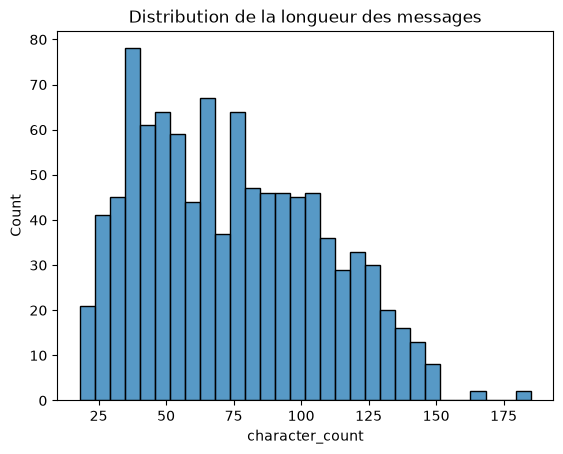

In [67]:
print("Valeurs manquantes :")
display(df[["content", label_column]].isna().sum())

print("Textes dupliqués :", df["content"].duplicated().sum())
print("Textes vides :", df["content"].fillna("").str.strip().eq("").sum())

df["character_count"] = df["content"].fillna("").str.len()

display(df["character_count"].describe())

sns.histplot(df["character_count"], bins=30)
plt.title("Distribution de la longueur des messages")
plt.show()

## 6. Normalisation des labels

Les valeurs `oui` et `non` sont converties en labels numériques et textuels tout en conservant l'annotation d'origine.

### 6.1 Création des labels normalisés

In [68]:
label_mapping = {
      "non": 0,
      "oui": 1,
  }

label_names = {
      0: "non_toxique",
      1: "toxique",
  }

def normalize_label(example):
      raw_label = example["literal_conclusion_annotator"].strip().lower()
      label = label_mapping[raw_label]

      return {
          "label": label,
          "label_text": label_names[label],
      }

small_train = small_train.map(normalize_label)

### 6.2 Vérification des labels

In [69]:
print(small_train.column_names)
print(small_train[0])

small_train.to_pandas()[["label", "label_text"]].value_counts()

['msg_id', 'content', 'literal_conclusion_annotator', 'CoT_explication', 'CoT_tons', 'CoT_intentions', 'CoT_categorie', 'CoT_labels', 'CoT_score', 'cot_final_question', 'direct_question', 'label', 'label_text']
{'msg_id': 'anon_msg_d111d5a2806e', 'content': "C'était spécial aussi, en gros t'avais la rivalité Chirac-Villepin contre Sarkozy, ils ont attendu le dernier moment pour pas donner raison à Sarko.", 'literal_conclusion_annotator': 'non', 'CoT_explication': '<think>\nExplication :\n**Sujet** : Rivalité politique en France.\n\n**Résumé** : Le message évoque la concurrence entre Jacques Chirac, Dominique de Villepin et Nicolas Sarkozy, précisant qu\'ils ont retardé leurs décisions pour ne pas accorder de validation à Sarkozy.\n\n**Sens probable** : Une stratégie politique visant à contrer l\'influence de Sarkozy.\n\n**Termes spécifiques** : "Sarko" est un diminutif de Sarkozy, un homme politique français.\n</think>', 'CoT_tons': "<think>\nTons :\nTons perçus : Neutre, Critique.\n\n

label  label_text 
0      non_toxique    500
1      toxique        500
Name: count, dtype: int64

## 7. Séparation des données

Le subset est séparé en **80 % d'entraînement** et **20 % de validation**. La stratification conserve la même proportion de messages toxiques et non toxiques dans chaque ensemble.

In [70]:
indices = np.arange(len(small_train))

train_indices, validation_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=small_train["label"],
)

train_dataset = small_train.select(train_indices.tolist())
validation_dataset = small_train.select(validation_indices.tolist())

### 7.1 Vérification de la séparation

In [71]:
print(f"Entraînement : {len(train_dataset)} exemples")
print(pd.Series(train_dataset["label_text"]).value_counts())

print(f"\nValidation : {len(validation_dataset)} exemples")
print(pd.Series(validation_dataset["label_text"]).value_counts())

Entraînement : 800 exemples
toxique        400
non_toxique    400
Name: count, dtype: int64

Validation : 200 exemples
toxique        100
non_toxique    100
Name: count, dtype: int64


## 8. Format conversationnel Gemma

Chaque exemple est converti en conversation avec un rôle système, le message à modérer et une réponse JSON structurée. La justification est extraite de `CoT_score` et les balises de raisonnement sont retirées. Ces justifications générées peuvent rester bruitées et devront être contrôlées avant l'entraînement complet.

In [72]:
SYSTEM_PROMPT = (
    "Tu es un modérateur francophone. Analyse le message et réponds uniquement "
    "avec un JSON valide contenant les clés 'label' et 'reason'. "
    "Le label doit être 'toxique' ou 'non_toxique' et la raison doit être courte."
)

def extract_reason(cot_score):
    reason = cot_score.split("Justification :", maxsplit=1)[-1]
    reason = reason.replace("<think>", "").replace("</think>", "")
    return " ".join(reason.split())

def format_as_messages(example):
    assistant_response = {
        "label": example["label_text"],
        "reason": extract_reason(example["CoT_score"]),
    }

    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["content"]},
            {"role": "assistant", "content": json.dumps(assistant_response, ensure_ascii=False)},
        ]
    }

formatted_train_dataset = train_dataset.map(format_as_messages)
formatted_validation_dataset = validation_dataset.map(format_as_messages)

### 8.1 Vérification du format

In [73]:
display(formatted_train_dataset[0]["messages"])

[{'role': 'system',
  'content': "Tu es un modérateur francophone. Analyse le message et réponds uniquement avec un JSON valide contenant les clés 'label' et 'reason'. Le label doit être 'toxique' ou 'non_toxique' et la raison doit être courte."},
 {'role': 'user', 'content': "Retourne de l'autre côté de la Méditerranée."},
 {'role': 'assistant',
  'content': '{"label": "toxique", "reason": "Le message rejette et exclut, véhiculant une hostilité envers un groupe spécifique sans incitation directe à la violence."}'}]

## 9. Chargement de Gemma 4 12B

Le checkpoint instruction-tuned publié par Unsloth est chargé en 4 bits pour limiter l'utilisation de la mémoire unifiée. Le premier lancement télécharge les poids du modèle.

In [74]:
MODEL_NAME = "unsloth/gemma-4-12b-it"
MAX_SEQ_LENGTH = 2048

model, tokenizer = FastModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 2436.73it/s]

Unsloth: Loading unsloth/gemma-4-12b-it via mlx-vlm (VLM, runtime 4-bit affine quantization)...



You are using a model of type `gemma4_unified` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You are using a model of type `gemma4_unified` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


[INFO] Quantized model with 5.497 bits per weight.


## 10. Évaluation de la baseline

Cette évaluation mesure les performances du modèle avant le fine-tuning. La réponse attendue n'est jamais incluse dans le prompt envoyé au modèle.

### 10.1 Fonction de modération

In [75]:
def moderate(message):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": message},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="np",
    )

    prompt_length = inputs["input_ids"].shape[-1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
    )

    decoder = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
    generated_tokens = outputs[0][prompt_length:]

    return decoder.decode(
        generated_tokens.tolist(),
        skip_special_tokens=True,
    ).strip()

### 10.2 Test manuel

Commencer par un exemple permet de vérifier le prompt et le format de sortie avant de lancer les 200 générations.

In [76]:
example = validation_dataset[0]

print("Message :", example["content"])
print("Réponse attendue :", example["label_text"])
print("Réponse de Gemma :", moderate(example["content"]))

Message : Tu peux chialer un peu plus fort stp le cuck ?
Réponse attendue : toxique
Réponse de Gemma : ```json
{
  "label": "toxique",
  "reason": "Contient une insulte homophobe/péjorative."
}
```


### 10.3 Lecture du label JSON

Les réponses non conformes au schéma demandé sont conservées sous le label `format_invalide` afin de ne pas masquer les erreurs du modèle.

In [77]:
def parse_label(response):
    start = response.find("{")
    end = response.rfind("}") + 1

    if start == -1 or end == 0:
        return "format_invalide"

    try:
        result = json.loads(response[start:end])
        label = result.get("label")

        if label in {"toxique", "non_toxique"}:
            return label
    except json.JSONDecodeError:
        pass

    return "format_invalide"

### 10.4 Test sur les 200 exemples

La barre `tqdm` affiche l'avancement. Cette boucle peut prendre du temps avec un modèle de 12 milliards de paramètres.

In [78]:
results = []

for example in tqdm(
    validation_dataset,
    total=len(validation_dataset),
    desc="Évaluation",
):
    raw_response = moderate(example["content"])

    results.append({
        "content": example["content"],
        "expected": example["label_text"],
        "predicted": parse_label(raw_response),
        "raw_response": raw_response,
    })

results_df = pd.DataFrame(results)
display(results_df.head())

Évaluation: 100%|██████████| 200/200 [05:21<00:00,  1.61s/it]


,content,expected,predicted,raw_response
0,Tu peux chialer un peu plus fort stp le cuck ?,toxique,toxique,"```json\n{\n ""label"": ""toxique"",\n ""reason"":..."
1,C'est le champion il fait ce qu'il veut,non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
2,Haha ma foi c'est déjà ça de pris !,non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
3,"C est pourtant simple, ils sont toujours là en...",non_toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."
4,CHEH pour ses voitures LGBTQIA++++,toxique,non_toxique,"```json\n{\n ""label"": ""non_toxique"",\n ""reas..."


### 10.5 Rapport de classification

La précision, le rappel et le F1-score sont plus informatifs que l'accuracy seule pour un problème de modération.

In [81]:
print(
    classification_report(
        results_df["expected"],
        results_df["predicted"],
        labels=["non_toxique", "toxique"],
        zero_division=0,
    )
)

print(
    "Formats invalides :",
    (results_df["predicted"] == "format_invalide").sum(),
)

              precision    recall  f1-score   support

 non_toxique       0.86      0.94      0.90       100
     toxique       0.93      0.85      0.89       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200

Formats invalides : 0


### 10.6 Matrice de confusion

La matrice permet de distinguer rapidement les faux positifs des faux négatifs.

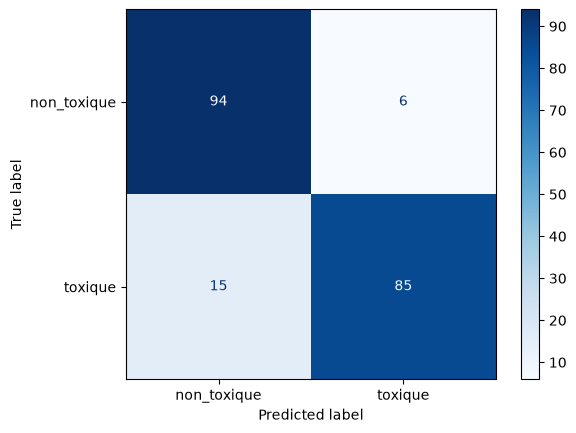

In [80]:
ConfusionMatrixDisplay.from_predictions(
    results_df["expected"],
    results_df["predicted"],
    labels=["non_toxique", "toxique"],
    cmap="Blues",
)

plt.show()